In [14]:
import os
from dotenv import load_dotenv
from langchain_google_genai import ChatGoogleGenerativeAI

load_dotenv()
#==========setup .env ===========
if os.getenv("GEMINI_API_KEY") is None:
    raise ValueError("GEMINI_API_KEY environment variable not set. Please set it in your .env file.")
else:
    print("GEMINI_API_KEY environment variable is set.")

GEMINI_API_KEY environment variable is set.


In [15]:
#==========setup model ===========
llm=ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite",
                                max_tokens=2048,temperature=0.5,
                                 api_key=os.getenv("GEMINI_API_KEY"))

In [16]:
# we will create agent using langgraph
# agent will generate social media content for a given topic
# and we will use pydantic to validate the output of the agent
# sequence of steps:
# 1. create a pydantic model for the agent state
# 2. create a function that will use the agent to generate content and validate it using the pydantic model
# 3. test the function with a sample topic


# **import needed lib**

In [47]:
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END


In [38]:
class LinkedinContent(BaseModel):
    " this is the pydantic model for the social media content generated by the agent "
    
    topic: str = Field(description="The topic for which social media content is being generated")
    post: str = Field(description="The generated social media content")
    post_id: str = Field(description="The unique identifier for the generated social media post")
    curated_post: str = Field(description="The curated version of the generated social media content")

demo_linkedin_content = LinkedinContent(topic="AI in Healthcare", 
                         post="AI is revolutionizing healthcare by improving diagnostics and patient care.", 
                         post_id="post_123",
                         curated_post="Discover how AI is transforming healthcare with enhanced diagnostics and patient care. #AI #Healthcare")
print(demo_linkedin_content)

topic='AI in Healthcare' post='AI is revolutionizing healthcare by improving diagnostics and patient care.' post_id='post_123' curated_post='Discover how AI is transforming healthcare with enhanced diagnostics and patient care. #AI #Healthcare'


In [83]:
#==========setup prompt template ===========
# is designed specialy for linkedin content generation
def generate_linkedin_content(topic: str) -> str:
    " this function will use the agent to generate social media content and validate it using the pydantic model "

    prompt = f"""
    You are a social media content generator. Your task is to create engaging and informative content for LinkedIn based on the given topic. 
    Please provide the following:
    1. A brief post about the topic.
    2. use gen z style to curate the post for better engagement.
    3. Make sure the content is professional and suitable for LinkedIn.

    the user will provide you with a topic, and you will generate the content accordingly.
    User Topic: {topic}
    
    output format:
    
    "original_post": "the generated social media content"
    

    """
    return prompt


def curate_linkedin_prompt(post: str) -> str:
    " this function will use the agent to curate the generated social media content for better engagement "

    prompt = f"""
    You are a social media content curator. Your task is to take the generated post and curate it in a way that it becomes more engaging and suitable for LinkedIn. 
    Please use a style that resonates with Gen Z while maintaining professionalism.

    Here is the post that needs to be curated:
    {post}

    output format:
    
    "curated_post": "the curated version of the generated social media content"
    

    """
    return prompt

In [84]:
def create_linkedin_content(state:LinkedinContent)->LinkedinContent:
    " this function will use the agent to generate social media content and validate it using the pydantic model "
    
    # 1. load prompt template for content generation
    content_generation_prompt = generate_linkedin_content(state.topic)
    # 2. use the agent to generate content
    generated_content = llm.invoke(content_generation_prompt)
    state.post_id= generated_content.id
    # 3. update the state with the generated content
    state.post = generated_content.content[0]["text"]
    return state


def curate_linkedin_content(state:LinkedinContent)->LinkedinContent:
    " this function will use the agent to curate the generated social media content for better engagement "
    
    # 1. load prompt template for content curation
    content_curation_prompt = curate_linkedin_prompt(state.post)
    # 2. use the agent to curate content
    curated_content = llm.invoke(content_curation_prompt)
    # 3. update the state with the curated content
    state.curated_post = curated_content.content[0]["text"]
    return state

# # test the function with a sample topic
# sample_topic = "The impact of AI on the job market"
# initial_state = LinkedinContent(topic=sample_topic, post="", curated_post="", post_id="")
# final_state = create_linkedin_content(initial_state)
# final_state = curate_linkedin_content(final_state)
# print(final_state)


In [85]:
#==========setup graph ===========
linkedin_graph = StateGraph(LinkedinContent)

linkedin_graph.add_node("create_linkedin_content", create_linkedin_content)
linkedin_graph.add_node("curate_linkedin_content", curate_linkedin_content)

linkedin_graph.add_edge(START, "create_linkedin_content")
linkedin_graph.add_edge("create_linkedin_content", "curate_linkedin_content")
linkedin_graph.add_edge("curate_linkedin_content", END)

# compile the graph
linkedin_graph=linkedin_graph.compile()

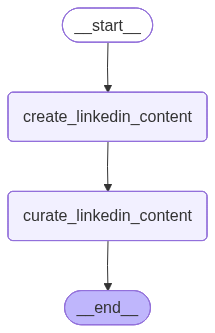

In [86]:
from IPython.display import Image,display
display(Image(linkedin_graph.get_graph().draw_mermaid_png()))

In [87]:
#==========setup intial state and run the graph ===========
sample_topic="The impact of AI on the job market"
state=LinkedinContent(topic=sample_topic, post="", curated_post="", post_id="")
linkedin_graph.invoke(state)

{'topic': 'The impact of AI on the job market',
 'post': '"original_post": "Is AI taking our jobs or just making us main characters in a more efficient plot? 🤖✨\n\nLet’s be real: the \'AI is replacing everyone\' narrative is officially mid. Instead of doom-scrolling about automation, let’s talk about the glow-up happening in the workforce. \n\nAI isn\'t here to replace the human touch—it’s here to handle the repetitive tasks that kill our vibe so we can focus on the high-level strategy and creative problem-solving that actually moves the needle. 📈\n\nThe move isn\'t to compete with AI; it’s to become the person who knows how to prompt it, leverage it, and integrate it into our workflows. We’re moving from \'doing the work\' to \'directing the output.\'\n\nThe future of work isn\'t about human vs. machine. It’s about human + machine = elite productivity. \n\nAre you using AI to level up your workflow, or are you still sleeping on it? Let’s discuss in the comments. 👇\n\n#FutureOfWork #AI

In [88]:
#==========setup intial state and run the graph ===========
sample_topic="الذكاء الاصطناعي وتأثيره على سوق العمل باللهجة المصرية"
state=LinkedinContent(topic=sample_topic, post="", curated_post="", post_id="")
output=linkedin_graph.invoke(state)

In [89]:
#=========== show output ===========

print("\n" + "=" * 60)
print("Generated Post")
print("=" * 60)

print(output["post"])

print("\n" + "=" * 60)
print("Curated Post")
print("=" * 60)

print(output["curated_post"])

print("\n" + "=" * 60)
print("Output Dictionary Keys")
print("=" * 60)

for key in output.keys():
    print(f"- {key}")


Generated Post
"original_post": "الذكاء الاصطناعي مبيسرقش الشغل.. هو بس بيغير قواعد اللعبة! 🤖✨

كتير مننا بيسأل: 'هل الـ AI هياخد مكاني؟' 
بص يا سيدي، الحقيقة إن الـ AI مش هيحل محل الشخص الشاطر، بس الشخص اللي بيعرف يستخدم الـ AI هو اللي هياخد مكان الشخص اللي رافض يطور نفسه. 

الموضوع مش 'إنسان ضد آلة'، الموضوع 'إنسان بآلة ضد إنسان من غيرها'. 

إحنا دلوقتي في عصر الـ Prompt Engineering والـ Automation. بدل ما تقضي ٥ ساعات في تاسك روتيني، الـ AI ممكن يخلصهولك في ٥ دقايق، وأنت تستغل باقي وقتك في الإبداع، التفكير الاستراتيجي، والـ Problem solving.. الحاجات اللي الآلة لسه مش عارفة تقلدنا فيها.

نصيحتي ليك؟ 
ماتخافش من التكنولوجيا، خاف إنك تفضل واقف مكانك. اتعلم، جرب، وشوف إزاي تقدر تطوع الأدوات دي عشان ترفع قيمتك في السوق. 

الـ AI مش تهديد، ده 'Superpower' لو عرفت تستخدمها صح. 🚀

إنتوا إيه رأيكم؟ بدأتوا تستخدموا أدوات الـ AI في شغلكم ولا لسه حاسين إن الموضوع 'Overrated'؟ شاركوني في الكومنتات! 👇

#الذكاء_الاصطناعي #مستقبل_العمل #AI #CareerGrowth #TechTrends #تطوير_الذات"

Curated Post
"cur

In [91]:
print(output["curated_post"])


"curated_post": "الذكاء الاصطناعي مبيسرقش الشغل.. هو بس بيعمل 'Upgrade' لقواعد اللعبة! 🤖✨

كتير بنسمع الـ Panic ده: 'هل الـ AI هياخد مكاني؟' 
بص يا صديقي، الحقيقة أبسط من كده بكتير: الـ AI مش هيحل محل الشخص الشاطر، بس الشخص اللي بيعرف يستخدم الـ AI هو اللي هياخد مكان الشخص اللي رافض يواكب. 

المعادلة مبقتش 'إنسان ضد آلة'، بقت 'إنسان بآلة ضد إنسان من غيرها'. 🧠⚡️

إحنا في عصر الـ Prompt Engineering والـ Automation. ليه تضيع ٥ ساعات في تاسك روتيني لما الـ AI ممكن يخلصهولك في ٥ دقايق؟ الوقت اللي وفرته ده هو اللي بتستثمره في الإبداع، التفكير الاستراتيجي، والـ Problem solving.. دي الـ Core بتاعنا اللي الآلة لسه مش عارفة تجيب آخره.

نصيحتي ليك؟ 
ماتخافش من التكنولوجيا، خاف إنك تفضل في الـ Comfort zone. اتعلم، جرب، وشوف إزاي الأدوات دي ممكن تكون الـ Superpower بتاعتك في السوق. 🚀

الموضوع مش تريند، ده واقع جديد. 

سؤال للنقاش: بدأتوا تدمجوا الـ AI في الـ Workflow بتاعكم ولا لسه حاسين إن الموضوع 'Overrated'؟ شاركوني رأيكم في الكومنتات! 👇

#الذكاء_الاصطناعي #AI #FutureOfWork #CareerGrowth #TechTr